In [1]:
from recs import *
import random

pd.options.display.max_colwidth = None
small_train = Path("../.data/MINDsmall_train")

GPU not detected.


This notebook gives an overview of the dataset and its main features. It starts with an overview of the structure of the data as two files and walk through the content of the columns. Then, it draws some early insights from it, such as the **date range, range of historic news, average clicks per impressions**.

## Dataset Structure

The dataset is split in:

File Name | Description
------------- | -------------
behaviors.tsv  | The click histories and impression logs of users
news.tsv  | The information of news articles

### Behaviours

The behaviors.tsv file contains the users' click behaviours. 

In [3]:
#| label: "tbl-behaviours"

user_behavior_data = pd.read_csv(small_train/'behaviors.tsv', sep='\t', header=None, 
            names=['user_id', 'time', 'news_history', 'impressions']
            )

user_behavior_data['impression_id'] = list(range(len(user_behavior_data)))
user_behavior_data = user_behavior_data.dropna(subset=['news_history'])

user_behavior_data[['impression_id','user_id', 'time', 'news_history', 'impressions']].sample(1)

,impression_id,user_id,time,news_history,impressions
107242,107241,U61207,11/12/2019 4:00:13 PM,N42989 N23653 N13374 N31801 N4607,N261-0 N20678-1 N27560-0 N17059-0


**A brief overview of the columns:**

- Impression ID. The ID of an impression.
- User ID. The anonymous ID of a user.
- Time. The impression time.
- History. The news click history (ID list of clicked news) of this user before this impression. The clicked news articles are ordered by time.
- Impressions. List of news displayed in this impression and user's click behaviors on them (1 for click and 0 for non-click). The orders of news in a impressions have been shuffled.

### news.tsv

The news.tsv file contains the news articles.

In [4]:
news_data = pd.read_csv(small_train/'news.tsv', sep='\t', header=None, 
            names=['news_id', 'category', 'subcategory', 'title', 'abstract', 
                   'URL', 'title_ents', 'abstract_ents' # omitted in usecolumns
                   ],
            usecols=[0, 1, 2, 3, 4]
            )

news_data.sample(1)

,news_id,category,subcategory,title,abstract
46864,N14011,news,newsus,Mayor Lucas announces public comment period after MLK Blvd. changed back to The Paseo,"KANSAS CITY, Mo. Kansas City Mayor Quinton Lucas announced on Tuesday a 90-day public comment period for suggestions on how to honor Dr. Martin Luther King Jr. after voters reversed a decision by city council to rename The Paseo in his honor. ""While many people of good heart believed renaming The Paseo Boulevard was a fitting honor, many others of good heart felt that other approaches were ..."


**A brief overview:**

- News ID: This ID is the key used in the history and impressions IDs.
- News Article Category
- News Article SubCategory
- Article Title
- Article Abstract
  
Omitted:

1. URLs. These are in the form `https://assets.msn.com/labs/mind/AAJRPWv.html`. Unfortunately these are expired. Please use a search engine with the news title and abstract instead. 
2. Named Entities in Title (used for graph embeddings).
3. Named Entities in Abstract (id.).

## Insights and Summary Statistics

First, to make the flow of data intuitive, a walk-through of the flow of a single user is presented. Next, we will ask a series of analytical questions to the data, and summarise these in a few tables and graphs. 

### Illustrating the Recommendation Task

As an aid to the understanding, we illustrate the workflow with a random user. We start by showing their reading history and the news articles the system recommends. Simply put, read articles are represented as `news_history` and the recommended articles as `impressions`. Here we show the reading history and the recommendation as `news_id`'s:

In [5]:
# Random choice to pick one user_id
rand_user = random.choice(range(len(user_behavior_data)))
hist_of_user = user_behavior_data.iloc[rand_user]['news_history'].split(' ')
print("Example history of impressions:\n", hist_of_user)

imp_of_user = user_behavior_data.iloc[rand_user]['impressions'].split(' ')
print("\nExample labelled impressions:\n", imp_of_user)

Example history of impressions:
 ['N13008', 'N44955', 'N39235', 'N38390', 'N31843', 'N56753', 'N63469', 'N38701', 'N24243', 'N31882', 'N46229', 'N64467', 'N43142', 'N33096', 'N41375', 'N45535', 'N55885', 'N4809']

Example labelled impressions:
 ['N287-1', 'N39010-0']


> The system labels the response of the user with a trailing 1 or 0. These represent "seen and clicked" and "seen but not clicked" respectively.
> 
> - The `news_history` corresponds to the *training data*, and 
> - The `impressions` corresponds to the *labels*.

**Mapping the `news_history` back to articles**

Next, to take this logic a step closer to the User Experience, the ids are mapped back to articles. 

In [6]:
# `news_history` mapped back to `news_id`
news_data.query('@hist_of_user in news_id')

,news_id,category,subcategory,title,abstract
1666,N38390,news,newsfactcheck,Fact check: Trump falsely claims his 2000 book demanded the killing of Osama bin Laden,"After announcing the death of ISIS leader Abu Bakr al-Baghdadi, President Donald Trump on Sunday took questions from journalists -- and made a major false claim about his past statements on Osama bin Laden."
3761,N31882,finance,personalfinance,Here's how the Fed rate cut affects you,"For consumers, lower rates do mean cheaper loans, but you'll earn less interest on savings accounts and maybe lose buying power over time."
5789,N63469,news,newsus,"A cop was told to 'tone down your gayness.' Now, he could get nearly $20 million, jury says.","We wanted to send a message, the jury foreman said. ""If you discriminate you are going to pay a big price. … You can't defend the indefensible."""
6829,N46229,lifestyle,lifestyleroyals,Meghan Markle Personally Calls British Politician to Thank Her for Orchestrating Letter of 'Solidarity',The Duchess of Sussex thanked the British female MP for supporting her amid media scrutiny.
7208,N55885,health,nutrition,How Much Do You Know About the Health Benefits of Turmeric?,Take this quick quiz to find out.
9740,N45535,news,newsus,DOJ sues Walmart for allegedly discriminating against a Navy reserve officer,The Department of Justice says that Walmart did not hire a naval reserve officer due to her mandatory two-week training in the summer of 2016.
11327,N24243,sports,football_nfl,Patriots reportedly release kicker Mike Nugent,"Related: NFL trade deadline tracker: Patriots rumors, news, instant analysis"
11423,N4809,finance,markets,UAE's central bank boss warns of rising risks after latest interest rate cut,"A recent move by the United Arab Emirates to cut interest rates will protect the currency and support the economy amid rising external risks, the country's top central banker told CNBC on Sunday"
13998,N39235,news,newscrime,"Florida woman allegedly flees 2 car crashes, kills driver in 3rd crash","A Florida woman who killed a 53-year-old man after running a red light and smashing into his Lexus on Saturday morning was in the process of fleeing two earlier car accidents when she caused the fatal collision, police said."
15019,N44955,video,peopleandplaces,STDs at record high in the U.S.,"The CDC says STDs including gonorrhea, syphilis and chlamydia have hit a record high with more than 2.4 million reported cases. We explain why."


**Mapping the clicked `impressions` back to articles**

To illustrate it further, the *clicked* articles of our sample user are mapped back to articles.

In [7]:
# The clicked `impressions` mapped back
clicked_imp_of_user = [imp.split('-')[0] for imp in imp_of_user if imp.endswith('1')]
news_data.query('@clicked_imp_of_user in news_id')

,news_id,category,subcategory,title,abstract
32602,N287,news,newscrime,Three school workers charged in death of special needs student,The student was reportedly restrained face-down for nearly an hour before becoming unresponsive


> **Key insight:** This illustates the logic of the recommendation dataset and its purpose in the prediction task. The data is labelled with 0s and 1s to represent whether an item was clicked. And each article is retrieved with the `news_id` from the news.tsv file. 
> 
> While 1s are true positives, 0s are false positives; the system falsely predicted that the user would click on them. 

## Summary Statistics

> As stated in the project proposal:   
> "MIND, short for MIcrosoft News Dataset, is composed of 6 weeks of the behaviour logs of 1 million users of MSN news. MIND contains 161,031 news articles and 24,155,470 behavior logs. MIND-small has 93,698 news articles, 50,000 users and 230,117 behavior logs."

### Base selection of the data

Given that the small dataset is a random sample of 50,000 users (and their behaviour logs) from the large dataset ([source](https://msnews.github.io/)), **we discard the small dataset** in these summary statistics. Of the large dataset, the test subset is unlabelled and is of little purpose to us, so **we discard the test set** as well. 

In [8]:
del user_behavior_data

Proceeding with the large dataset, we look at test, train, and dev sets in aggregate.

In [2]:
file_paths = [file for dir in Path(".data").glob("*large*") 
                    for file in dir.glob("behaviors.tsv")
                    if 'test' not in dir.as_posix() and 'new_dev' not in  dir.as_posix()] # omit test set 

user_behavior_data = pd.concat([pd.read_csv(file_path, sep='\t', header=None, 
            names=['user_id', 'time', 'news_history', 'impressions']) for file_path in file_paths])

In [3]:
user_behavior_data.shape

(2609219, 4)

In [4]:
arr = user_behavior_data.news_history.str.split().tolist() # i.e. list of lists
len(arr)

2609219

In [5]:
new = []
errors = 0
for ar in arr:
    try:
        new.extend(ar) 
    except: errors += 1 # some are nan instead of sublists

In [ ]:
errors # ~nan

60762

In [6]:
len(list(new)) 

85912031

> 86 million history records

In [7]:
len(list(set(new)))

79937

> ...of which 80k unique

In [9]:
arr2 = user_behavior_data.impressions.str.split().tolist()
new = []
errors = 0
clicks = 0
for ar in arr2:
    for a in ar:
        labelled_imp = a.split('-')
        new.append(labelled_imp[0])
        if labelled_imp[1] == '1':
            clicks += 1 

len(list(new)), len(list(set(new))), clicks

(97592931, 29309, 3958501)

> 107 million logged candidates, of which 30k unique. And 4.3 million clicks

In [11]:
clicks / len(list(new))

0.04056134967398407

In [5]:
file_paths = [file for dir in Path("../.data").glob("*large*") 
                    for file in dir.glob("news.tsv")
                    if 'test' not in dir.as_posix() and 'new_dev' not in  dir.as_posix()] # omit test set

news_data = pd.concat([pd.read_csv(file_path, sep='\t', header=None, 
            names=['news_id', 'category', 'subcategory', 'title', 'abstract'],
            usecols=[0, 1, 2, 3, 4]) for file_path in file_paths])

In [11]:
print(f"There are a total of {user_behavior_data.shape[0]} behaviour records, and {news_data.shape[0]} news articles")

There are a total of 2609219 behaviour records, and 173550 news articles


In [12]:
# Total unique users
user_behavior_data.drop_duplicates('user_id').shape[0]

750434

> In summary, we proceed with **over 170k news articles and 2.6 million behaviour logs covering over 750k users.**
>
> Note that the total data spans 5 million behaviour logs of 880k users, and 300k news articles. However, the test appears intended for competitions given its absence of labels. For unlabeled data, we may look instead at recent news data, from NewsCatcherAPI.

## Key Insights

Now that we have a sense of the data's content and scale, the next section will highlight several key insights derived from it. 

We start with some pertinent questions:

- Do many users have multiple records? 
- If so, how many records per user do we have?
- Following from 1 and 2, is the user feedback integrated?
- Are returning users seeing repetition in their recommendations?
- What is the date range?
- What are the most prevalent categories and subcategories?
- Are there cold-start issues?
- Are users well represented?
- What is the distribution of history, impression and word lengths?
- What is the item popularity distribution?
   
#### 1. Multiple records per User


In [ ]:
# The number of unique users, average number of return visits (3.5), median, and max (107)
user_behavior_data.user_id.value_counts().describe()

count    750434.000000
mean          3.476947
std           3.388294
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         107.000000
Name: user_id, dtype: float64


#### 2. Records per user

How many records are there for each `user_id`? Below we can see that the distribution has a long tail, with a some users returning up to 108 times, while the majority visited the platform 3 times or less.

In [14]:
records_per_user = user_behavior_data.groupby('user_id')['user_id'].count().sort_values(ascending=False)

f"{round(records_per_user.index.shape[0], -3)} users produced {round(user_behavior_data.shape[0],-3)} session logs."

'750000 users produced 2609000 session logs.'

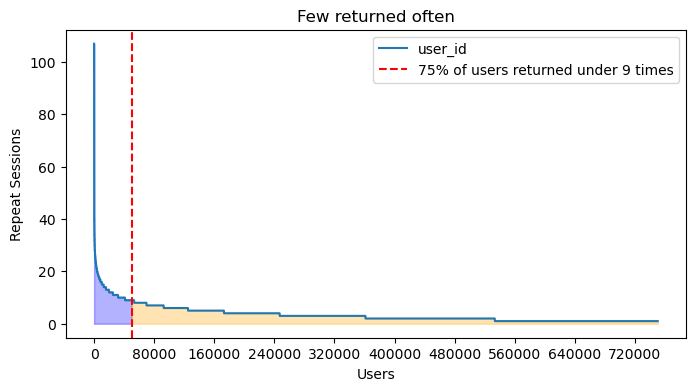

In [ ]:
#| label: "fig-long-tail"
#| fig-cap: "Most users did not come back often"

pct = 0.25

# Find the number of items that cover a significant pct of the records
cum_percent = records_per_user.cumsum() / records_per_user.sum()
head_count = (cum_percent <= pct).sum()

# Plot the freq_counts
ax = records_per_user.plot(title="Few returned often", 
                      ylabel='Repeat Sessions',
                      xlabel='Users',
                      figsize=(8, 4))

# Fill the head and tail in different colours
x = range(len(records_per_user))
ax.fill_between(x[:head_count], records_per_user.iloc[:head_count], color="blue", alpha=0.3)
ax.fill_between(x[head_count:], records_per_user.iloc[head_count:], color="orange", alpha=0.3)

# Add a vertical line at the cutoff
ax.axvline(x=head_count, color="red", linestyle="--",
           label=f"75% of users returned under 9 times")

xticks = [(i,i) for i,c in enumerate(records_per_user.index) if i % 80000 == 0]
ticks, labels = list(zip(*xticks))
ax.set_xticks(ticks)
ax.set_xticklabels(labels) 

ax.legend()
plt.show()

#### History per user

A common problem for recommender (more so for collaborative filtering) is the sparsity of user and item representation.  

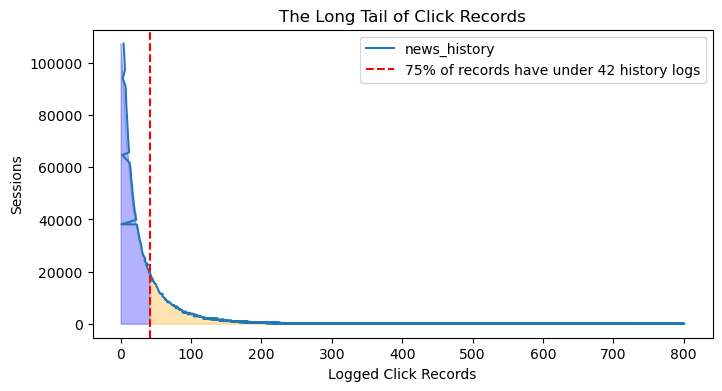

In [ ]:
#| label: fig-long-tail-of-histories
#| fig-cap: "The Long Tail of Click Records"

pct = 0.75
user_history_dist = user_behavior_data.news_history.str.split().dropna().apply(len)

# Count the frequencies
freq_counts = user_history_dist.value_counts().sort_values(ascending=False)

cum_percent = freq_counts.cumsum() / freq_counts.sum()
head_count = (cum_percent <= pct).sum()

# Plot the freq_counts
ax = freq_counts.plot(title="The Long Tail of Click Records", 
                      ylabel='Sessions',
                      xlabel='Logged Click Records',
                      figsize=(8, 4))

# Fill the head and tail in different colours
x = range(len(freq_counts))
ax.fill_between(x[:head_count], freq_counts.iloc[:head_count], color="blue", alpha=0.3)
ax.fill_between(x[head_count:], freq_counts.iloc[head_count:], color="orange", alpha=0.3)

# Add a vertical line at the cutoff
ax.axvline(x=head_count, color="red", linestyle="--",
           label=f"{pct*100:.0f}% of records have under {head_count} history logs")

ax.legend()
plt.show()

In [ ]:
user_history_dist.describe() # number of sessions, avg. session length, median, as well as the maximum

count   2675206.000000
mean         33.281450
std          40.528066
min           1.000000
25%           8.000000
50%          19.000000
75%          43.000000
max         801.000000
Name: news_history, dtype: float64

In [27]:
del records_per_user

> **[Quote Falk on the fact that this is common]**

#### 3. Is the user feedback integrated?

Despite the high level of feedback from returning users, the `news_history`'s are not extended to incorporate the user impressions, as seen below. This is counter-intuitive, as a user's feedback is expected to inform future recommendations. One possible explanation for this, may be the model's offline training regime. Training is typically computationally expensive and may therefore be executed intermittently. 

Below we show one such returning user:

In [34]:
# Random returning user
returning = user_behavior_data.user_id.duplicated()

rand_user = user_behavior_data[returning].user_id.sample(1).values[0]
user_behavior_data.loc[user_behavior_data.user_id == rand_user]

,user_id,time,news_history,impressions
663104,U514059,11/13/2019 8:17:42 AM,N17483 N35060 N87446 N35362 N128965 N63237 N70014 N10711 N49262 N39592 N14611 N54948 N40228 N115998 N118860 N46994 N15371 N83193 N62159 N43418 N6668 N114571 N44826 N27133 N78130 N88075 N91597 N56409 N1707 N1503 N77135 N10811 N120031 N87236 N15800 N45196 N14979,N74453-0 N65313-0 N58198-0 N96729-0 N72609-0 N125161-1 N47925-0 N84689-0 N72485-0 N46415-0 N69950-0 N12040-0 N46229-0 N20964-0 N127155-0 N93856-0 N129969-0 N95525-0 N96373-0 N99964-0 N10285-0 N80994-0 N10802-0 N12681-0 N53474-0
699655,U514059,11/14/2019 8:49:24 AM,N17483 N35060 N87446 N35362 N128965 N63237 N70014 N10711 N49262 N39592 N14611 N54948 N40228 N115998 N118860 N46994 N15371 N83193 N62159 N43418 N6668 N114571 N44826 N27133 N78130 N88075 N91597 N56409 N1707 N1503 N77135 N10811 N120031 N87236 N15800 N45196 N14979,N117376-0 N84430-0 N25751-0 N56873-0 N58641-0 N46145-0 N880-0 N41710-0 N66244-0 N96805-0 N29441-0 N65446-0 N91390-1 N108405-0 N41547-0 N76665-0 N102458-0 N51163-0 N29544-0 N105407-0 N20364-0 N113519-0 N48015-0 N110627-0 N85664-0
1456283,U514059,11/14/2019 8:58:29 AM,N17483 N35060 N87446 N35362 N128965 N63237 N70014 N10711 N49262 N39592 N14611 N54948 N40228 N115998 N118860 N46994 N15371 N83193 N62159 N43418 N6668 N114571 N44826 N27133 N78130 N88075 N91597 N56409 N1707 N1503 N77135 N10811 N120031 N87236 N15800 N45196 N14979,N90423-0 N31102-0 N84430-0 N66244-0 N123968-0 N113519-0 N85664-0 N96805-0 N91390-1 N105407-0 N3356-0 N99187-0 N39403-0 N56873-0 N880-0 N102458-0 N117376-0 N80784-0 N110925-0 N129503-0 N29544-0 N46229-1 N76665-0 N41547-0 N46145-0 N112125-0 N83503-0 N41710-0 N29504-0 N79081-0 N18405-0 N29441-0 N19983-0 N34172-0 N48015-0 N110603-0 N125161-0 N117242-0
116474,U514059,11/15/2019 8:13:56 AM,N17483 N35060 N87446 N35362 N128965 N63237 N70014 N10711 N49262 N39592 N14611 N54948 N40228 N115998 N118860 N46994 N15371 N83193 N62159 N43418 N6668 N114571 N44826 N27133 N78130 N88075 N91597 N56409 N1707 N1503 N77135 N10811 N120031 N87236 N15800 N45196 N14979,N30206-0 N18258-0 N105271-0 N98252-0 N28962-0 N12974-0 N30582-0 N44453-0 N52388-0 N3663-0 N47548-0 N122640-0 N34548-0 N72977-0 N62800-0 N21356-0 N18356-0 N92476-1 N16161-0 N37648-0 N69938-0 N54368-0 N38555-0 N24958-0 N18190-0 N33901-0 N91731-0 N29160-0 N100425-0 N35304-0 N95541-0 N83491-0 N123209-0 N27669-0 N32757-0 N7382-0 N127357-0 N122944-0 N58465-0 N46894-0 N19586-0 N48833-0 N12384-0 N14719-0 N130076-0 N64914-0 N32286-0 N110967-0 N40742-0 N92462-0
358550,U514059,11/15/2019 5:17:12 PM,N17483 N35060 N87446 N35362 N128965 N63237 N70014 N10711 N49262 N39592 N14611 N54948 N40228 N115998 N118860 N46994 N15371 N83193 N62159 N43418 N6668 N114571 N44826 N27133 N78130 N88075 N91597 N56409 N1707 N1503 N77135 N10811 N120031 N87236 N15800 N45196 N14979,N87192-1 N123462-0


#### 4. Are returning users seeing repetition in their recommendations?
   
Equally important for the quality of recommendation is this: do returning users see different content every time?

count    533415.000000
mean          1.077786
std           0.137743
min           1.000000
25%           1.000000
50%           1.000000
75%           1.105263
max           3.000000
Name: impressions, dtype: float64

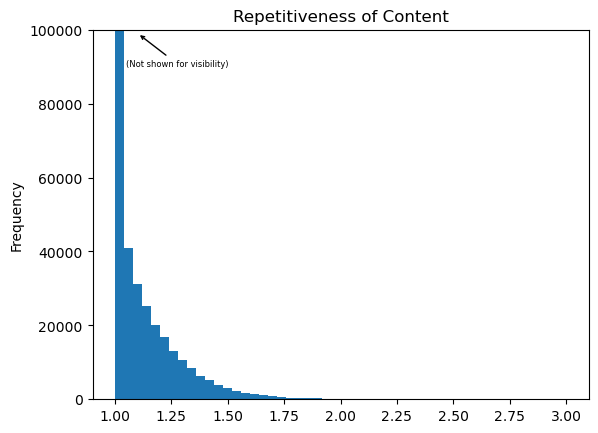

In [17]:
# For each returning use, concatenate all its impressions
concat = user_behavior_data[returning].groupby('user_id')['impressions'].agg(lambda x: ' '.join(x))

# Compare the list with the set 
concat_split = concat.str.split(' ')
repetition_dist = concat_split.apply(lambda x: len(x)) / concat_split.apply(lambda x: len(set(x)))

repetition_dist.plot.hist(bins=50, 
                          title='Repetitiveness of Content', 
                          xlabel='Recurrence of News Articles (one = once)', 
                          ylabel='',
                          ylim=(0,100000)
                          )

plt.annotate(
    '(Not shown for visibility)', 
    xy=(1.1, 99000),
    xytext=(1.05, 90000), 
    arrowprops=dict(facecolor='black', arrowstyle='->'), 
    fontsize=6
)
repetition_dist.describe()

> The average of 1.078 indicates that repetition is rare. Most see content only once. 

#### 5. Date range

In [18]:
# For our entire dataset
user_behavior_data.time = pd.to_datetime(user_behavior_data.time)

(user_behavior_data.time.max() - user_behavior_data.time.min())

Timedelta('6 days 23:59:43')

In [ ]:
# Using a bespoke function for a detailed look
from recs.data_df import train_test_split

train, test = train_test_split()
train.time = pd.to_datetime(train.time)
test.time = pd.to_datetime(test.time)
train.time.min(), train.time.max(), test.time.min(), test.time.max()

(Timestamp('2019-11-09 00:00:00'),
 Timestamp('2019-11-14 23:59:59'),
 Timestamp('2019-11-15 00:00:00'),
 Timestamp('2019-11-15 23:59:43'))

**Key Insights:**

- The split in `train` and `dev` (henceforth referred to as `test`) follows the arrow of time. This is good.
- Train set covers 9 to 14 November 2019, and the test set covers the 15th.
- This sequential property is essential, as it keeps a user's `news_history` strictly in the past; shuffling would introduce leakage of labels into the training set.
- Also note that the official test dataset follows that same pattern; it covers the next 7 days. Unfortunately, however, this dataset does not contain labels.

In [20]:
# del test, train

#### 6. Categories and subcategories

Further insight can be derived from the categories assigned to each news items. This project will not use category data as such. However, inevitably, the distributions of categories will inform the nature of the scaled features in TF-IDF, the topics in the topic model, and the Q-K-V-matrices learned by the transformer layers. 

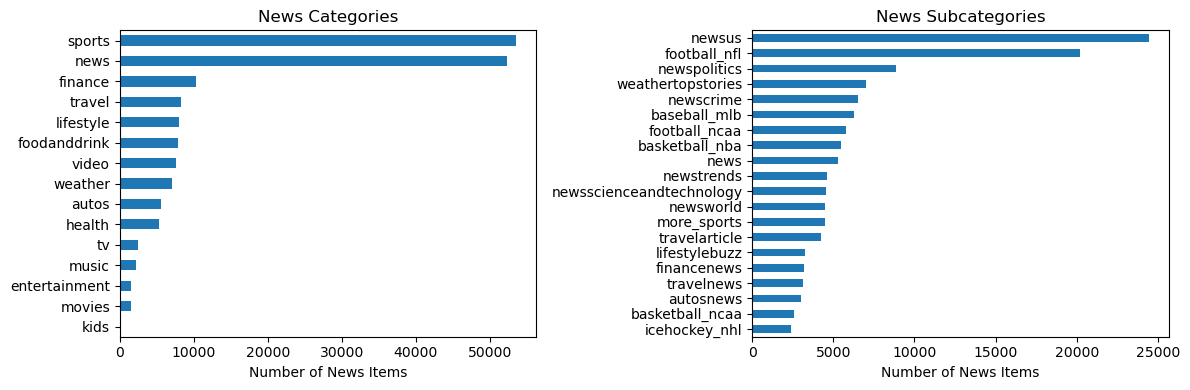

In [ ]:
#| label: fig-categories
#| fig-cap: "This project will not use category data as such. However, inevitably, the distributions of categories will inform the nature of the scaled features in TF-IDF, the topics in the topic model, and the Q-K-V-matrices learned by the transformer layers."

fig, axs = plt.subplots(1,2, figsize=(12,4))
news_data.category.value_counts().head(15).plot.barh(    
    title="News Categories",
    xlabel='Number of News Items',
    ax=axs[0])
axs[0].invert_yaxis()

subcategory_count = news_data.subcategory.value_counts()
subcategory_count.head(20).iloc[::-1]\
    .plot.barh(title="News Subcategories", ax=axs[1],
    xlabel='Number of News Items',)

plt.tight_layout() 
plt.show()

**A closer look at the `news` category**

Let's now turn to the subcategories for the category `news`. This shows that the US news dominates in the dataset, albeit only 14%. 

In [22]:
news_cat = news_data.groupby('category')['subcategory'].value_counts().loc['news']
news_cat.head(10)

subcategory
newsus                      24438
newspolitics                 8888
newscrime                    6548
newsscienceandtechnology     4580
newsworld                    4497
newsoffbeat                  1516
newsopinion                   675
newsgoodnews                  378
newsbusiness                  241
elections-2020-us             218
Name: subcategory, dtype: int64

In [23]:
# Percentage of newsus in all articles
news_cat.iloc[0] / news_data.shape[0]

0.1408124459809853

**We can do the same for `sports`**

In [24]:
# Idem for sports
sports_cat = news_data.groupby('category')['subcategory'].value_counts().loc['sports']
sports_cat.head(10)

subcategory
football_nfl       20174
baseball_mlb        6259
football_ncaa       5774
basketball_nba      5447
more_sports         4486
basketball_ncaa     2594
icehockey_nhl       2366
mma                 1730
golf                1358
racing              1167
Name: subcategory, dtype: int64

**Plotting the `title lengths` for the different categories**

In [25]:
news_data['title_len'] = news_data.title.str.split().apply(len)

/tmp/ipykernel_130910/3716950447.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(


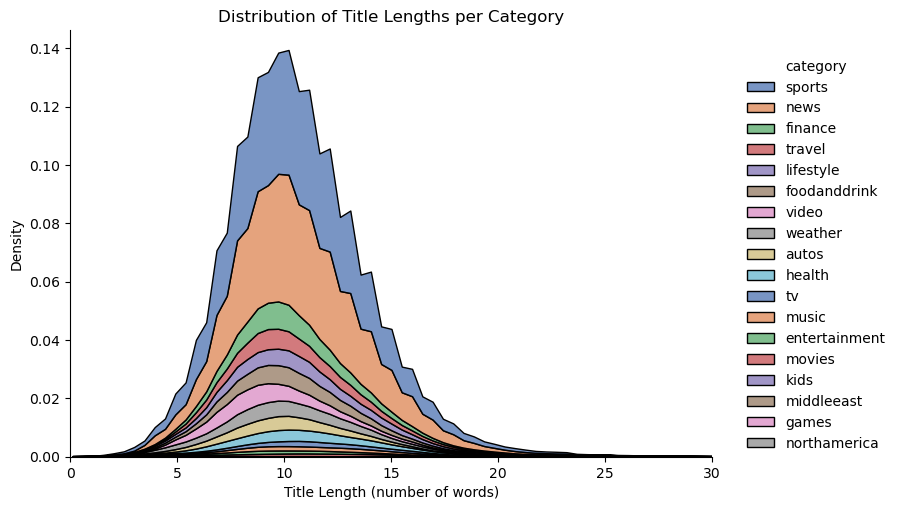

In [ ]:
#| label: fig-title-lengths-per-category
#| fig-cap: "Distribution of title lengths per category."

import seaborn as sns

sns.displot(
    data=news_data,
    x='title_len',
    hue='category',
    multiple='stack', 
    palette='deep',
    kind='kde',
    hue_order=news_data.category.value_counts().index,
    aspect=1.5
)
plt.xlim(0,30)
plt.xlabel('Title Length (number of words)')
plt.title('Distribution of Title Lengths per Category')
plt.show()

In [ ]:
# News title lengths
news_data.title.str.split().apply(len).describe()

count    173550.000000
mean         10.691945
std           3.269471
min           1.000000
25%           9.000000
50%          10.000000
75%          13.000000
max          95.000000
Name: title, dtype: float64

**Plotting the biggest categories and subcategories**

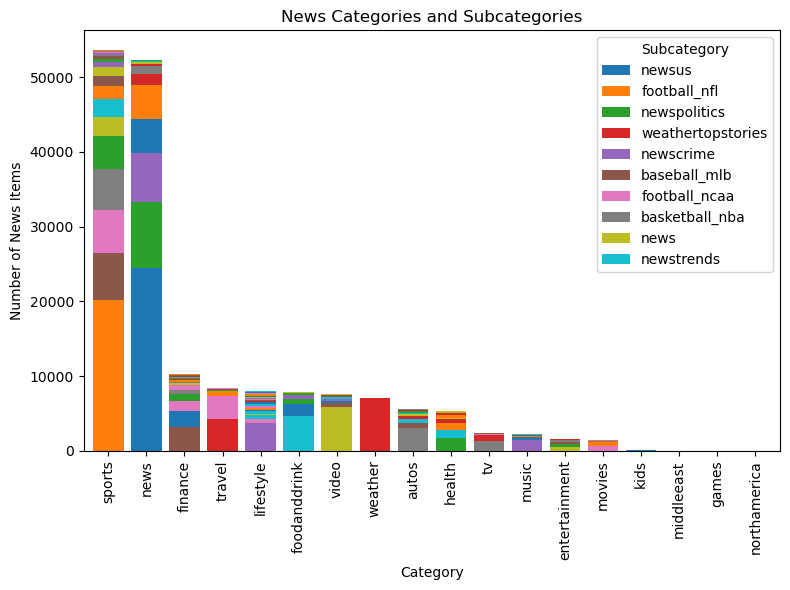

In [49]:
#| label: fig-news-categories-and-subcategories
#| fig-cap: "The categories and subcategories in the MIND dataset"

# Compute counts for category and subcategory
freq_counts = news_data[['category', 'subcategory']].value_counts()

# Pivot so that each category becomes a row and subcategories become columns.
pivot_counts = freq_counts.unstack(fill_value=0)

# Order the categories (rows) by their total count
pivot_counts = pivot_counts.loc[pivot_counts.sum(axis=1).sort_values(ascending=False).index]

# Order subcategories (columns) by overall frequency 
subcat_totals = pivot_counts.sum(axis=0).sort_values(ascending=False)

# Plot a stacked bar chart
ax = pivot_counts[subcat_totals.index].plot(kind='bar', stacked=True, figsize=(8, 6), width=0.8)
plt.xlabel('Category')
plt.ylabel('Number of News Items')
plt.title('News Categories and Subcategories')

# Filter legend items: show only the top subcategories 
top_subcats = subcat_totals.head(10).index
handles, labels = ax.get_legend_handles_labels()
filtered_handles = []
filtered_labels = []
for handle, label in zip(handles, labels):
    if label in top_subcats:
        filtered_handles.append(handle)
        filtered_labels.append(label)
ax.legend(filtered_handles, filtered_labels, title='Subcategory') #, bbox_to_anchor=(1, 1.02), loc='upper left')

plt.tight_layout()
plt.show()

#### 7. Are there cold-start issues?

How many users in the dataset have no history?

In [28]:
user_behavior_data.news_history.isna().sum()

57335

In percent:

In [29]:
user_behavior_data.news_history.isna().sum() / user_behavior_data.shape[0]

0.021974008314365332

#### 8. Is there a good representation of users

If we're to use the test set with user profiles created with the training set, we need a training set that is sufficiently representative. In other words, we need large numbers of returning users to predict the preferences of returning users.

In [31]:
# from recs.data_loader_pd import train_test_split

# train, test = train_test_split()
len(set(train.user_id) & set(test.user_id))

255990

In [32]:
del train, test

### 9. Distribution of history-length, impression-length, avg session length per user

To determine padding length, we need to know how much sequence data we have. 

Interestingly, they follow a long-tial distribtion, or exponential decay.

**A look at `news_history` lengths** 

This is the number of read (clicked) news articles for each row in the log.

In [69]:
pd.set_option('display.float_format', '{:.6f}'.format)

count    2.551884e+06
mean     3.366612e+01
std      4.093759e+01
min      1.000000e+00
25%      8.000000e+00
50%      2.000000e+01
75%      4.300000e+01
max      8.010000e+02
Name: history_lens, dtype: float64

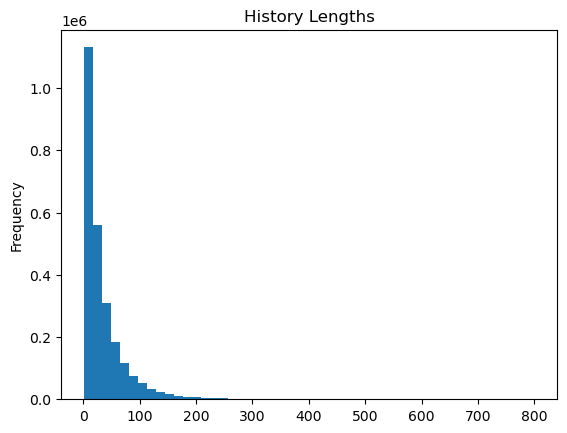

In [50]:
user_behavior_data.dropna(subset='news_history', inplace=True)
user_behavior_data['history_lens'] = user_behavior_data.news_history.str.split().apply(len)
user_behavior_data['history_lens'].plot.hist(bins=50, title="History Lengths")
user_behavior_data['history_lens'].describe()

**A look at `impressions` lengths** 

This is the number of recommended (clicked and unclicked) news articles for each row in the log.

count    2.551884e+06
mean     3.740279e+01
std      3.885758e+01
min      2.000000e+00
25%      1.000000e+01
50%      2.400000e+01
75%      5.100000e+01
max      3.000000e+02
Name: imp_len, dtype: float64

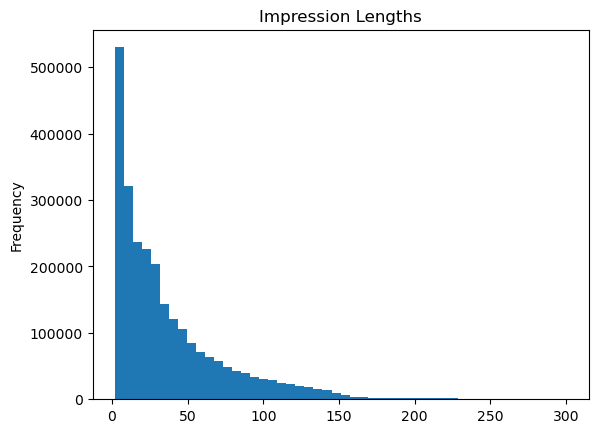

In [51]:
user_behavior_data.dropna(subset='impressions', inplace=True)
user_behavior_data['imp_len'] = user_behavior_data.impressions.str.split().apply(len)
user_behavior_data['imp_len'].plot.hist(bins=50, title="Impression Lengths") 
user_behavior_data['imp_len'].describe()

**A look at `clicked impressions` lengths** 

This is the number of 1s for each impression in each session.

count    2.609219e+06
mean     1.517121e+00
std      1.172378e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      5.100000e+01
Name: pos_len, dtype: float64

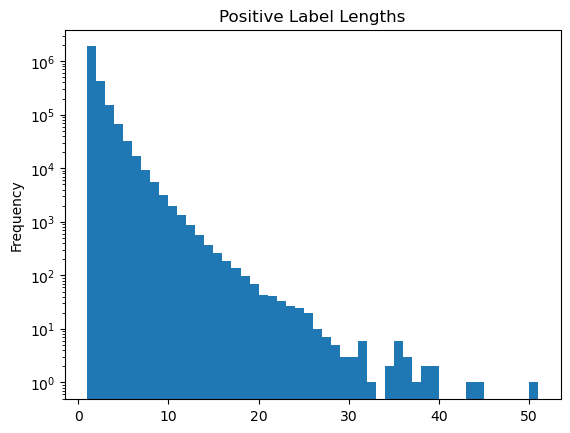

In [11]:
user_behavior_data['clean_imps'] = user_behavior_data['impressions'].apply(lambda row: [imp.split('-')[0] for imp in row.split()])
user_behavior_data['labels'] = user_behavior_data['impressions'].apply(lambda row: [imp.split('-')[1] for imp in row.split()])

# Sum (the ones in) the labels
user_behavior_data['pos_len'] = user_behavior_data.labels.apply(lambda row: sum([int(r) for r in row]))
user_behavior_data['pos_len'].plot.hist(bins=50, logy=True, title="Positive Label Lengths")
user_behavior_data['pos_len'].describe()

> There are very few instances with multiple positive labels (clicks), however they exist, with some reading sessions reaching up to 51 clicks.
>
> We can set padding to the 3rd quartile:
> - `news_history`: 43 (original paper uses 50)
> - `impressions` / `labels`: 51 (not specified in orig paper, but 20)

In [18]:
# The proportion of 1s (clicks) vs 0s (unclicked items)
user_behavior_data['pos_len'].sum() / user_behavior_data['impressions'].str.split().apply(len).sum()

0.04056134967398407

> So, 96% of recommendations are **not** clicked. (So if we were to use accuracy, that would our baseline. (Or do like [here](https://www.kaggle.com/code/fazalhaq6559/recommender-system) and pretend 96% is our performance))

TODO: groupby on user_id to find out how this differs by user:

- Do some users consistently have longer impression lists? 
- Do some users consistently click while other consistently don't?

The model is likely to learn this.


---

### 10. Comparing different measures for Popularity

We can aggregate history and clicks to represent popularity. This gives the novelty metrics more to work with.

Here we will:

1. Collect all the clicks
2. compare to all the candidates: 
   1. how many are clicked; 
   2. are some clicked very often? 
   3. if so, can we create an inverse to popularity? 
   4. Should we correct (weight) the distribution?

In [4]:
# Initialise
data = DataLoader(data_size='large')

# Can get all (beyond the sequence lengths)
# histories, imprs, labels = zip(*data.init_behaviors(data.train))

# Or truncated sequence lengths
histories, imprs, labels = data.init_padded_behaviors(data.train)

Combine histories and clicked impressions to represent popularity.

In [5]:
# Collect all clicks
clicks = []
for imp, lab in zip(imprs, labels):
    for i, l in zip(imp, lab):
        if l == 1:
            clicks.append(i)

In [6]:
# collect unique histories 
# Filter sessions on unique users

file_path = Path("../.data/MINDlarge_train")

user_behavior_data = pd.read_csv(file_path/'behaviors.tsv', sep='\t', header=None, 
            names=['user_id', 'time', 'news_history', 'impressions'])

user_behavior_data.drop_duplicates('user_id', inplace=True)
count_histories = user_behavior_data.news_history.str.split().tolist()

# Flatten and remove nans
count_histories = [hi for st in count_histories if isinstance(st, list) for hi in st]

# Lookup indices (Using indices rather than `U12561` user ids.)
count_histories = [data.news_id2index[i] for i in count_histories]

hist_series = pd.Series(count_histories)
h_count = hist_series.value_counts()
h_count

25993    67149
32709    58844
50257    47644
4418     46372
15210    44051
         ...  
4846         1
26931        1
51619        1
7859         1
39584        1
Length: 79546, dtype: int64

In [7]:
# 67149 reading histories include:
data.news_titles[25993].numpy().decode()

"Kevin Spacey Won't Be Charged in Sexual Assault Case After Accuser Dies"

In [8]:
clicks = pd.Series(clicks)
click_count = clicks.value_counts()
# click_count

In [9]:
# instead of concat use .add() 
all_click_hist = h_count.add(click_count, fill_value=0).astype(int)
all_click_hist = all_click_hist.sort_values(ascending=False)

In [10]:
all_click_hist.describe() # of all clicked items

count    92089.000000
mean       169.589234
std       1122.295771
min          1.000000
25%          2.000000
50%          4.000000
75%         19.000000
max      67149.000000
dtype: float64

Note: on 110k unique items, 40k features are clicked (historically + in the train set)

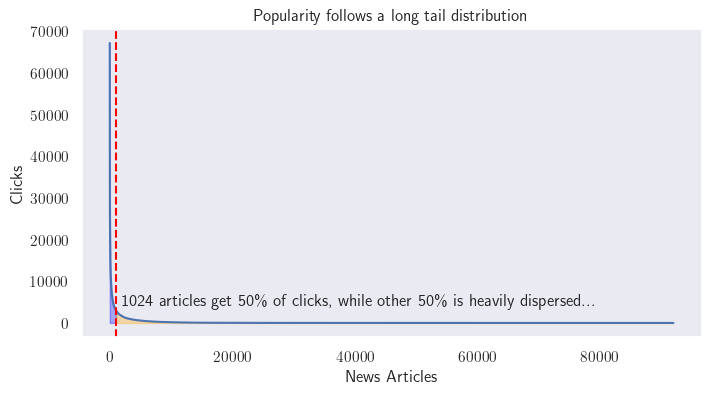

In [12]:
#| label: "fig-popularity"
#| fig-cap: "Popularity follows a long tail distribution"

pct = 0.50

# Find the number of items that cover a significant pct of the records
cum_percent = all_click_hist.cumsum() / all_click_hist.sum()
head_count = (cum_percent <= pct).sum()

x = range(len(all_click_hist))
fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.lineplot(all_click_hist.values, ax=ax)
ax.fill_between(x[:head_count], all_click_hist.iloc[:head_count], color="blue", alpha=0.3)
ax.fill_between(x[head_count:], all_click_hist.iloc[head_count:], color="orange", alpha=0.3)

#  Add a vertical line at the cutoff
ax.axvline(x=head_count, color="red", linestyle="--",)
ax.text(x=head_count+1000, y=4000, s=f'{head_count} articles get 50\% of clicks, while other 50\% is heavily dispersed...')

ax.set_title('Popularity follows a long tail distribution')
ax.set_xlabel('News Articles')
ax.set_ylabel('Clicks')
# ax.legend()
plt.show()

In [ ]:
data.news_titles.numpy()[all_click_hist.index[:5]]

array([b"Kevin Spacey Won't Be Charged in Sexual Assault Case After Accuser Dies",
       b"Heidi Klum's 2019 Halloween Costume Transformation Is Mind-Blowing   But, Like, What Is It?",
       b'The News In Cartoons',
       b'Joe Biden reportedly denied Communion at a South Carolina church because of his stance on abortion',
       b"Four flight attendants were arrested in Miami's airport after bringing in thousands in cash, police say"],
      dtype=object)


---

### 11. Popularity bias on MSN news

The **most often recommended** candidates (regardless of label value) reveal significant overlap between the popularity recommender and the candidate lists as produced by MSN News.

In [ ]:
# the same is now here 
# data.get_popularity()
# pop_50 = data.item_popularity.most_common(50)

In [ ]:
all_candidates = [imp for i in imprs for imp in i if imp != 0] # flattened
pop = Counter(all_candidates)
pop_50 = pop.most_common(50)
pop_50 = list(zip(*pop_50))[0]

# Allow indexing
top_50 = np.array(pop_50)

# inspect
print(data.news_titles[top_50])

[b'Opinion: Colin Kaepernick is about to get what he deserves: a chance'
 b'Meghan Markle and Hillary Clinton Secretly Spent the Afternoon Together at Frogmore Cottage'
 b'South Carolina teen gets life in prison for deadly elementary school shooting'
 b'30 Best Black Friday Deals from Costco'
 b"THEN AND NOW: What all your favorite '90s stars are doing today"
 b"Taylor Swift Rep Hits Back at Big Machine, Claims She's Actually Owed $7.9 Million in Unpaid Royalties"
 b"The Real Reason McDonald's Keeps the Filet-O-Fish on Their Menu"
 b'The most talked about movie moments of the 2010s'
 b"Report: Police investigating woman's death after Redskins' player Montae Nicholson took her to hospital"
 b'66 Cool Tech Gifts Anyone Would Be Thrilled to Receive'
 b'Cows swept away by Hurricane Dorian found alive   but how?'
 b"Pete Davidson, Kaia Gerber Are Dating, Trying to Stay 'Low Profile'"
 b"13 Reasons Why's Christian Navarro Slams Disney for Casting 'the White Guy' in The Little Mermaid"
 b'Sur

In [ ]:
# now we compare the `most recommended` by MSN with the average popularity embedding
embedding_matrix = np.load(data_folder/'embedding_matrix_large_cls.npy')
popularity_vector = np.mean(embedding_matrix[top_50], axis=0)

ranked_by_pop = []
for t in tqdm(top_50):
    news_embedding = embedding_matrix[t]
    by_pop_ranking = cosine_similarity([popularity_vector], [news_embedding])[0][0]
    ranked_by_pop.append(by_pop_ranking)

  0%|          | 0/50 [00:00<?, ?it/s]

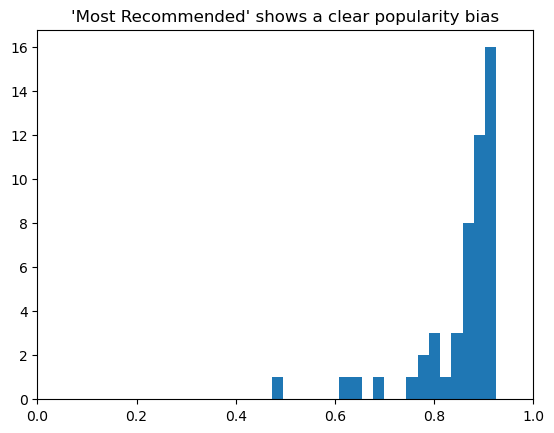

In [ ]:
plt.hist(ranked_by_pop, bins=20)
plt.title("'Most Recommended' shows a clear popularity bias")
plt.xlim((0,1))
plt.show()

In [ ]:
for title, pop in zip(data.news_titles[top_50], ranked_by_pop):
    print(f"Popularity: {pop:.3f} \nArticle title:\n {title.decode()}\n\n")

Popularity: 0.855 
Article title:
 Taylor Swift Rep Hits Back at Big Machine, Claims She's Actually Owed $7.9 Million in Unpaid Royalties


Popularity: 0.919 
Article title:
 Opinion: Colin Kaepernick is about to get what he deserves: a chance


Popularity: 0.866 
Article title:
 66 Cool Tech Gifts Anyone Would Be Thrilled to Receive


Popularity: 0.879 
Article title:
 Report: Police investigating woman's death after Redskins' player Montae Nicholson took her to hospital


Popularity: 0.885 
Article title:
 13 Reasons Why's Christian Navarro Slams Disney for Casting 'the White Guy' in The Little Mermaid


Popularity: 0.900 
Article title:
 THEN AND NOW: What all your favorite '90s stars are doing today


Popularity: 0.769 
Article title:
 Pete Davidson, Kaia Gerber Are Dating, Trying to Stay 'Low Profile'


Popularity: 0.899 
Article title:
 Meghan Markle and Hillary Clinton Secretly Spent the Afternoon Together at Frogmore Cottage


Popularity: 0.920 
Article title:
 The most talked 

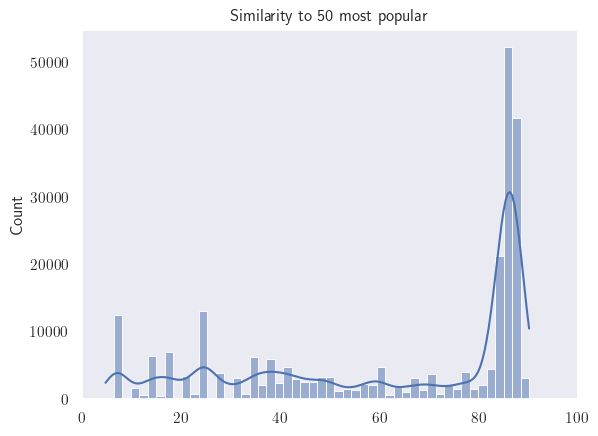

In [ ]:
#| label: "fig-sim-to-pop"
#| fig-cap: "Most recommendation lists have high similarity to the popularity vector"

# Representing every user session in terms of similarity to the popularity vector
dist = [np.mean(cand_list) * 100 for cand_list in ranked_by_pop]
ax = sns.histplot(dist, bins=50, kde=True)
ax.set_xlim(0,100)
ax.set_title('Similarity to 50 most popular')
plt.show()

This suggest that most users read popular news. Alternatively, perhaps the MSN recommender has a high popularity bias. See below (most recommend items).

In [ ]:
# Inspect similarity to most popular
indices = np.where((dist > 0.722) & (dist < 0.7221))[0]

print(indices.shape)
np.array(data.news_titles)[imprs[indices]]

(236,)


array([["'It's not over': Sarah Palin says she is fighting to repair her marriage",
        'The 50 cheapest places to buy land in America',
        'See what your favorite stars look like without makeup', ...,
        'Look of the Day',
        'Trump, Erdogan to meet as thorny issues stress relations',
        "Jennifer Lopez Debuted the Sleek Seasonal Bob You'll Want to Copy"],
       ['100 Incredible Christmas Tree Decorating Ideas',
        'We Tried 9 Packaged Stuffings and There Was a Clear Winner',
        "This Is What It's Like to Give Up Alcohol For a Week", ...,
        'Celebrity plastic surgery transformations',
        "Trump says he's not watching impeachment hearing   then critiques it",
        'Massachusetts fire lieutenant dies battling house fire'],
       ["The Best Backstage Moments From the 2019 E! People's Choice Awards",
        'Neil Young Says U.S. Citizenship Application Delayed By Marijuana Use',
        'Subprime mortgages keep minting cash for former Bea

In [ ]:
# Inspect similarity to most popular
indices = np.where((dist > 0.1) & (dist < 0.101))[0]

print(indices.shape)
np.array(data.news_titles)[imprs[indices]]

(7,)


array([['One in 5 children live below the poverty line: Here are the states with the highest number of kids dependent on free lunches',
        'Fashion hits and misses from the 2019 Country Music Association Awards',
        'Lawmakers, More Polite in Private, Get Aggressive in Public Hearing',
        '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',
        ''],
       ['Richest 1% of Americans Close to Surpassing Wealth of Middle Class',
        'The 25 most iconic film quotes', 'The News In Cartoons', '', '',
        '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['The News In Cartoons',
        'Sears, Kmart: More Bad News For 2 Major Retailers In Ohio',
        'The 25 most iconic film quotes', '', '', '', '', '', '', '', '',
        '', '', '', '', '', '', '', '', ''],
       ['50 amazing gifts for every type of person and budget',
        'RANKED: The 30 countries where expats are happiest',
        'One in 5 children live below the poverty l